#**Data Loading**

In [ ]:
import os
import shutil

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
shutil.move("kaggle.json", "/root/.kaggle/")

'/root/.kaggle/kaggle.json'

In [ ]:
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files(
  "shashwatwork/knee-osteoarthritis-dataset-with-severity",
  path='/content',
  unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity


In [ ]:
os.system('rm -rf /content/auto_test')

0

In [ ]:
train_dir = "/content/train"
val_dir = "/content/val"
test_dir = "/content/test"

In [ ]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class_names = ['0', '1', '2', '3', '4']

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  class_names=class_names,
  color_mode='rgb',
  batch_size=None,
  image_size=(224, 224),
  shuffle=True,
  seed=101,
  data_format='channels_last'
)

Found 5778 files belonging to 5 classes.


In [ ]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  val_dir,
  labels='inferred',
  label_mode='int',
  class_names=class_names,
  color_mode='rgb',
  image_size=(224, 224),
  batch_size=None,
  shuffle=True,
  seed=101,
  data_format='channels_last'
)

Found 826 files belonging to 5 classes.


In [ ]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  test_dir,
  labels='inferred',
  label_mode='int',
  class_names=class_names,
  color_mode='rgb',
  image_size=(224, 224),
  batch_size=None,
  shuffle=True,
  seed=101,
  data_format='channels_last'
)

Found 1656 files belonging to 5 classes.


In [ ]:
rescale_layer = tf.keras.layers.Rescaling(1/255)

def rescale(image, label):
    image = rescale_layer(image)
    return image, label

train_dataset = train_dataset.map(rescale)
val_dataset = val_dataset.map(rescale)
test_dataset = test_dataset.map(rescale)

#**Augmentation**

In [ ]:
import tensorflow as tf
import albumentations as A
import numpy as np
import cv2
from collections import defaultdict

# Define augmentation pipeline
augmentations = [
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.Rotate(limit=(-45, 90), p=1),
    A.RandomCrop(height=201, width=201, p=1),  # 0.1 crop from 224x224
    A.RandomCrop(height=179, width=179, p=1),  # 0.2 crop from 224x224
    A.RandomGamma(gamma_limit=(80, 120), p=1),
    A.RandomBrightnessContrast(p=1),
    A.ChannelShuffle(p=1),
    A.InvertImg(p=1)
]

# Function to apply augmentation
def apply_augmentations(image):
    image = image.numpy()
    aug = np.random.choice(augmentations)
    augmented_image = aug(image=image)["image"]
    augmented_image = cv2.resize(augmented_image, (224, 224))
    return augmented_image

# Load dataset counts
max_samples = 1500

# Function to yield augmented dataset
def dataset_generator():
    for image, label in train_dataset:  # Assuming train_dataset is already defined
        yield image, label.numpy()

    # Augment only required samples
    dataset_dict = defaultdict(list)
    for image, label in train_dataset:
        dataset_dict[label.numpy()].append(image)

    for class_id, images in dataset_dict.items():
        current_count = len(images)
        required_augmentations = max_samples - current_count
        img_idx = 0
        while required_augmentations > 0:
            img = images[img_idx % current_count]
            aug_img = apply_augmentations(img)
            yield aug_img, class_id
            required_augmentations -= 1
            img_idx += 1

# Create dataset from generator
balanced_train_dataset = tf.data.Dataset.from_generator(dataset_generator,
                                                  output_signature=(
                                                      tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
                                                      tf.TensorSpec(shape=(), dtype=tf.int32)
                                                  ))

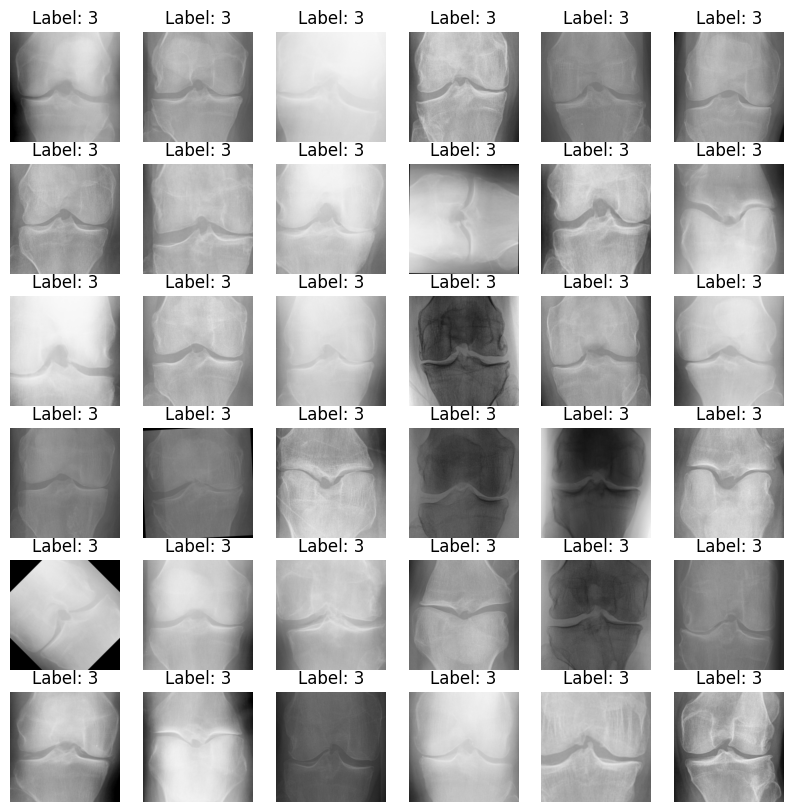

In [ ]:
# Plot images with labels
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(balanced_train_dataset.skip(5778).take(36)):
    image = image.numpy()  # Convert tensor to NumPy array

    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf
from collections import defaultdict

# Dictionary to store class counts
class_counts = defaultdict(int)

# Iterate through the dataset
for _, label in balanced_train_dataset:
    class_counts[int(label.numpy())] += 1

# Print the results
for class_label, count in sorted(class_counts.items()):
    print(f"Class {class_label}: {count} images")

Class 0: 2286 images
Class 1: 1500 images
Class 2: 1516 images
Class 3: 1500 images
Class 4: 1500 images


In [ ]:
num_samples = sum(1 for _ in balanced_train_dataset)  # Count total samples
steps_per_epoch = num_samples // 32  # Floor division ensures integer steps

In [ ]:
balanced_train_dataset = balanced_train_dataset.shuffle(500).repeat().batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.shuffle(500).batch(1).prefetch(tf.data.AUTOTUNE)

#**CallBacks**

In [ ]:
#Saves the most with best performance among all epochs
checkpoint_path = "/content/best_model.keras"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
#Reduces learning rate when there is no increase in accuracy
learning_rate_callback = tf.keras.callbacks.ReduceLROnPlateau(
  monitor='val_sparse_categorical_accuracy',
  factor=0.3,
  patience=3,
  min_lr=1e-6,
  min_delta=0.01,
)

#**Model Architecture**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, LeakyReLU, ReLU, Input, Reshape, MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D

In [ ]:
# Load VGG16 model without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add additional layers to extract features from VGG16
x = base_model.output

x = Flatten()(x)
x = Dense(4096, activation='relu')(x)
x = Dense(4096, activation='relu')(x)
x = Dense(1024, activation='relu')(x)  # Feature extraction layer

x = Reshape((32, 32, 1))(x)

x = Conv2D(32, (3, 3), padding='same')(x)
x = LeakyReLU(alpha=0.001)(x)
x = Dropout(0.3)(x)

x = Conv2D(32, (3, 3), padding='same')(x)
x = LeakyReLU(alpha=0.001)(x)
x = Dropout(0.3)(x)

x = Conv2D(32, (3, 3), padding='same')(x)
x = LeakyReLU(alpha=0.001)(x)
x = Dropout(0.3)(x)

x = Conv2D(16, (3, 3), padding='same')(x)
x = LeakyReLU(alpha=0.001)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Flatten and Dense Layers
x = Flatten()(x)
x = Dense(1000, activation='leaky_relu')(x)

x = Dense(1000, activation='leaky_relu')(x)

# Final Classification Layer
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 143,582,317 (547.72 MB)

 Trainable params: 143,582,317 (547.72 MB)

 Non-trainable params: 0 (0.00 B)

#**Model Training**

In [ ]:
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam
from keras.metrics import SparseCategoricalAccuracy

model.compile(optimizer = Adam(0.001),
              loss = SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

In [ ]:
history = model.fit(
    balanced_train_dataset,
    validation_data = val_dataset,
    epochs = 20,
    steps_per_epoch = steps_per_epoch,
    verbose = 1,
    callbacks = [checkpoint_callback, learning_rate_callback])

Epoch 1/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - loss: 3.5195 - sparse_categorical_accuracy: 0.3866
Epoch 1: val_sparse_categorical_accuracy improved from -inf to 0.03269, saving model to /content/best_model.keras
259/259 ━━━━━━━━━━━━━━━━━━━━ 240s 756ms/step - loss: 3.5126 - sparse_categorical_accuracy: 0.3868 - val_loss: 4.7015 - val_sparse_categorical_accuracy: 0.0327 - learning_rate: 0.0010
Epoch 2/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - loss: 1.8107 - sparse_categorical_accuracy: 0.3240
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.03269
259/259 ━━━━━━━━━━━━━━━━━━━━ 154s 595ms/step - loss: 1.8097 - sparse_categorical_accuracy: 0.3244 - val_loss: 6.0491 - val_sparse_categorical_accuracy: 0.0327 - learning_rate: 0.0010
Epoch 3/20
165/259 ━━━━━━━━━━━━━━━━━━━━ 43s 463ms/step - loss: 1.6967 - sparse_categorical_accuracy: 0.2669